# Business Insights and Strategic Recommendations

## Project Objective

This notebook summarises the key business findings from the Pet Insurance Claims Risk Analytics project.

The analysis combines exploratory data analysis, engineered pricing variables and predictive modelling to identify the primary drivers of claim severity and provide actionable recommendations for pricing and underwriting.

Unlike the previous notebooks, which focus on data preparation and model development, this report is written from a business perspective and is intended for decision-makers.

## Executive Summary

This project analysed over 188,000 insurance claims and developed a predictive framework for estimating expected pet insurance claim severity.

Key findings include:

• Age is the strongest driver of expected claim severity.

• Comprehensive policies consistently generate the highest expected claim costs.

• Certain breeds, particularly Dachshunds and French Bulldogs, exhibit substantially higher expected claim severity than other breeds.

• Gradient Boosting achieved the best predictive performance among the evaluated machine learning models.

Overall, the results demonstrate that combining customer characteristics with engineered pricing variables provides a practical framework for risk segmentation and claim severity prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/pet_insurance_claims.csv")

print(df.shape)

(188318, 142)


## Key Insight 1 — Pet Age is the Strongest Risk Driver

Older pets consistently generate higher expected claim amounts.

Both exploratory analysis and machine learning models identified pet age as the most influential pricing factor.

Business implication:

Premium adjustments should increase progressively with pet age to reflect higher expected veterinary costs.

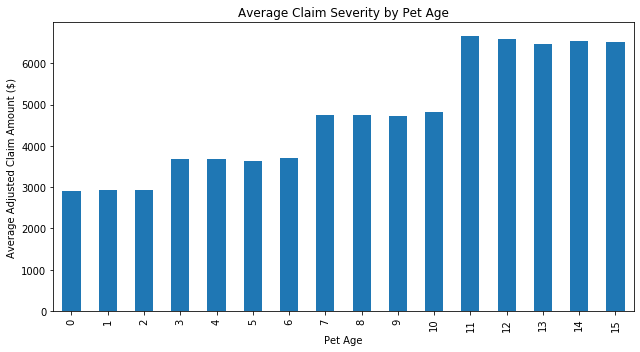

In [2]:
age_summary = (
    df.groupby("pet_age")["adjusted_claim_amount"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(9, 5))

age_summary.plot(kind="bar")

plt.title("Average Claim Severity by Pet Age")
plt.xlabel("Pet Age")
plt.ylabel("Average Adjusted Claim Amount ($)")

plt.tight_layout()
plt.show()

## Key Insight 2 — Coverage Level Significantly Increases Claim Severity

Comprehensive policies consistently exhibit higher expected claim severity than Standard and Basic policies.

Business implication:

Pricing should continue to differentiate between coverage tiers, ensuring that additional insurer exposure is appropriately reflected in premiums.

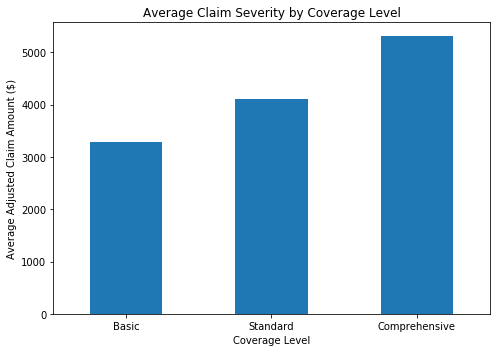

In [3]:
coverage_summary = (
    df.groupby("coverage_level")["adjusted_claim_amount"]
    .mean()
    .reindex(["Basic", "Standard", "Comprehensive"])
)

plt.figure(figsize=(7, 5))

coverage_summary.plot(kind="bar")

plt.title("Average Claim Severity by Coverage Level")
plt.xlabel("Coverage Level")
plt.ylabel("Average Adjusted Claim Amount ($)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Key Insight 3 — Breed-specific Risk Remains Important

Several breeds—including Dachshunds, French Bulldogs and Persian cats—generate consistently higher expected claim costs.

Business implication:

Breed-specific pricing or underwriting adjustments may improve portfolio profitability.

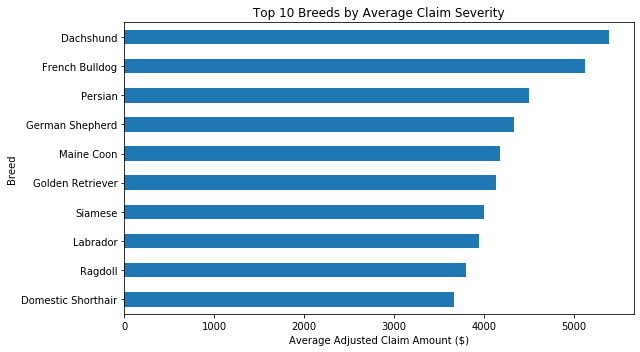

In [4]:
breed_summary = (
    df.groupby("breed")["adjusted_claim_amount"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))

breed_summary.sort_values().plot(kind="barh")

plt.title("Top 10 Breeds by Average Claim Severity")
plt.xlabel("Average Adjusted Claim Amount ($)")
plt.ylabel("Breed")

plt.tight_layout()
plt.show()

## Key Insight 4 — High-risk Segments are Driven by Multiple Factors

The highest expected claim severity occurs when multiple risk factors interact.

For example:

• High-risk breeds

• Older pets

• Comprehensive policies

Business implication:

Pricing decisions should consider combinations of customer characteristics rather than individual factors in isolation.

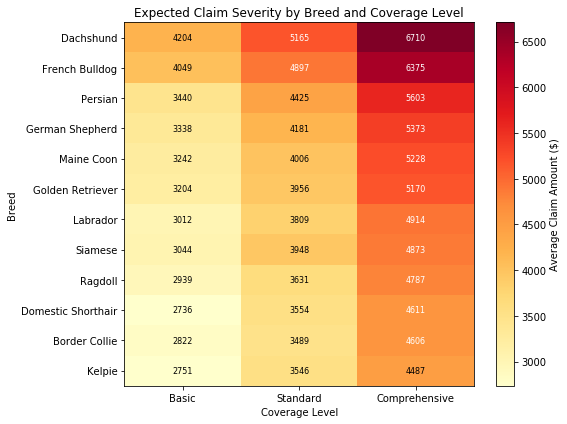

In [5]:
risk_matrix = (
    df.pivot_table(
        values="adjusted_claim_amount",
        index="breed",
        columns="coverage_level",
        aggfunc="mean"
    )
)

risk_matrix = risk_matrix[["Basic", "Standard", "Comprehensive"]]

risk_matrix = risk_matrix.sort_values(
    by="Comprehensive",
    ascending=False
)

plt.figure(figsize=(8, 6))

plt.imshow(
    risk_matrix,
    aspect="auto",
    cmap="YlOrRd"
)

plt.colorbar(label="Average Claim Amount ($)")

plt.xticks(
    range(len(risk_matrix.columns)),
    risk_matrix.columns
)

plt.yticks(
    range(len(risk_matrix.index)),
    risk_matrix.index
)

plt.title("Expected Claim Severity by Breed and Coverage Level")
plt.xlabel("Coverage Level")
plt.ylabel("Breed")

for i in range(len(risk_matrix.index)):
    for j in range(len(risk_matrix.columns)):
        value = risk_matrix.iloc[i, j]
        text_color = "white" if value > 4500 else "black"

        plt.text(
            j,
            i,
            f"{value:.0f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8
        )

plt.tight_layout()
plt.show()


## Predictive Modelling Summary

Four regression models were evaluated:

- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Gradient Boosting achieved the strongest overall predictive performance, producing the lowest prediction error and highest explanatory power among the evaluated models.

Although the performance improvement over Linear Regression was modest, ensemble learning demonstrated improved capability for modelling complex pricing relationships.

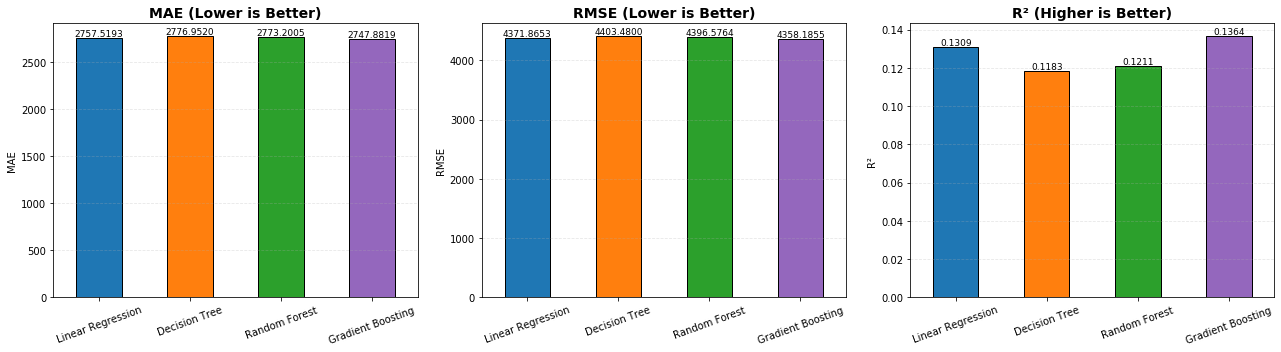

Metric,MAE,RMSE,R²
Linear Regression,2757.5193,4371.8653,0.1309
Decision Tree,2776.9520,4403.4800,0.1183
Random Forest,2773.2005,4396.5764,0.1211
Gradient Boosting,2747.8819,4358.1855,0.1364


In [8]:
performance = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    
    "Linear Regression": [
        2757.519297,
        4371.865296,
        0.130945
    ],
    
    "Decision Tree": [
        2776.952036,
        4403.480046,
        0.118331
    ],
    
    "Random Forest": [
        2773.200495,
        4396.576437,
        0.121093
    ],
    
    "Gradient Boosting": [
        2747.881884,
        4358.185500,
        0.136375
    ]
})

perf_df = performance.set_index("Metric").T.round(4)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["MAE", "RMSE", "R²"]
titles = [
    "MAE (Lower is Better)",
    "RMSE (Lower is Better)",
    "R² (Higher is Better)"
]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]

for ax, metric, title in zip(axes, metrics, titles):

    perf_df[metric].plot(
        kind="bar",
        ax=ax,
        color=colors,
        edgecolor="black"
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_ylabel(metric)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.tick_params(axis="x", rotation=20)

    for p in ax.patches:
        height = p.get_height()

        ax.annotate(
            f"{height:.4f}",
            (p.get_x() + p.get_width()/2, height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

display(perf_df)

# Business Recommendations

Based on the findings from this project, the following recommendations are proposed.

### Recommendation 1

Increase premium adjustments for older pets.

### Recommendation 2

Maintain differentiated pricing across coverage tiers.

### Recommendation 3

Review underwriting rules for high-risk breed and coverage combinations.

### Recommendation 4

Adopt Gradient Boosting as the preferred predictive model for future claim severity estimation.

### Recommendation 5

Continue collecting richer policyholder and veterinary information to improve predictive performance.

# Future Improvements

Several opportunities exist to further improve this project.

• Incorporate real veterinary diagnosis information.

• Include customer demographics and geographic location.

• Introduce claim frequency modelling in addition to claim severity.

• Perform hyperparameter optimisation using GridSearchCV.

• Deploy the predictive model as an interactive web application.

• Develop a production Power BI dashboard for business users.

# Project limitations

Although the predictive models identify meaningful risk patterns, the project uses synthetic insurance data and therefore should not be interpreted as production-ready pricing models.

Real-world deployment would require richer customer information, claim history, veterinary diagnosis data and regulatory validation.

# Conclusion

This project demonstrates an end-to-end insurance analytics workflow, from data preparation and feature engineering to predictive modelling and business recommendations.

The findings highlight the importance of combining statistical analysis, machine learning and domain knowledge to support pricing, underwriting and portfolio management decisions.

Overall, the project illustrates how data analytics can be used to transform raw insurance claims into actionable business insights.